
#Domain-Specific vs General-Purpose LLMs for XAI
## Heart Disease Prediction - Framingham Heart Study
**MSc Artificial Intelligence** - 2026

# Data Loading and Exploratory Data Analysis

This notebook performs the initial exploration of the Framingham Heart Study dataset.

The objectives are to:

- Load the dataset
- Inspect the dataset structure
- Explore feature types
- Identify missing values
- Examine the target variable
- Generate descriptive statistics

This notebook forms the foundation for the preprocessing and modelling stages developed later in the project.

## 1.Loading the Framingham HEART Study Dataset

In [11]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
# Project Configuration
from pathlib import Path
RANDOM_STATE = 42
DATA_PATH = Path("data/framingham.csv")
print("Dataset loaded")

Dataset loaded


In [13]:
# Importing the Libraries necessary
import warnings
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

np.random.seed(RANDOM_STATE)

print("Libraries imported ")

Libraries imported 


## 2. Exploratory Data Analysis (EDA)

In [14]:
# Load Framingham Heart Study dataset
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/framingham.csv")
df.info()
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
df.describe().round(2)
print(f"Dataset loaded successfully.")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   int64  
 1   age              4240 non-null   int64  
 2   education        4135 non-null   float64
 3   currentSmoker    4240 non-null   int64  
 4   cigsPerDay       4211 non-null   float64
 5   BPMeds           4187 non-null   float64
 6   prevalentStroke  4240 non-null   int64  
 7   prevalentHyp     4240 non-null   int64  
 8   diabetes         4240 non-null   int64  
 9   totChol          4190 non-null   float64
 10  sysBP            4240 non-null   float64
 11  diaBP            4240 non-null   float64
 12  BMI              4221 non-null   float64
 13  heartRate        4239 non-null   float64
 14  glucose          3852 non-null   float64
 15  TenYearCHD       4240 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 530.1 KB
Rows: 4240
Co

,Missing Count,Missing Percentage
glucose,388,9.15
education,105,2.48
BPMeds,53,1.25
totChol,50,1.18
cigsPerDay,29,0.68
BMI,19,0.45
heartRate,1,0.02


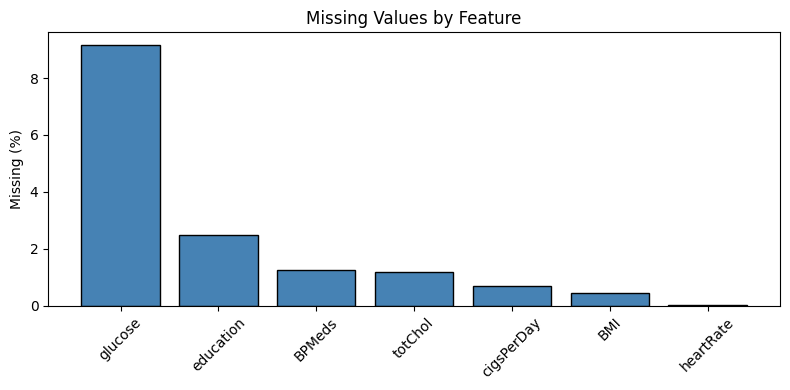

In [15]:
# Missing Value Analysis
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"Missing Count": missing,"Missing Percentage": missing_pct})
missing_df = (missing_df[missing_df["Missing Count"] > 0].sort_values("Missing Percentage", ascending=False))
display(missing_df)

plt.figure(figsize=(8,4))

plt.bar(missing_df.index,missing_df["Missing Percentage"],color="steelblue",edgecolor="black")

plt.title("Missing Values by Feature")
plt.ylabel("Missing (%)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

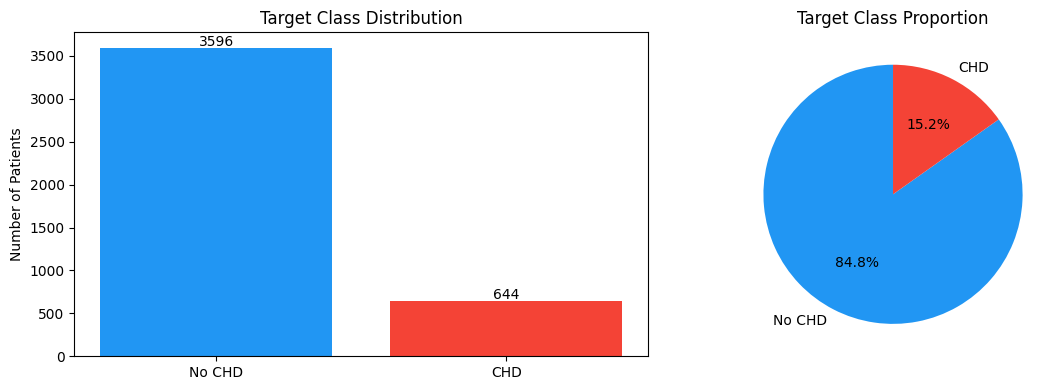

In [26]:
# Target Distribution
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
counts = df["TenYearCHD"].value_counts()

ax[0].bar(["No CHD","CHD"],counts.values,color=['#2196F3', '#F44336'])
ax[0].set_title("Target Class Distribution")
ax[0].set_ylabel("Number of Patients")

for i, value in enumerate(counts.values):
  ax[0].text(i, value + 20, str(value), ha="center")

ax[1].pie(counts.values,labels=["No CHD","CHD"],autopct="%.1f%%",colors=['#2196F3', '#F44336'],startangle=90)
ax[1].set_title("Target Class Proportion")
plt.tight_layout()
plt.show()

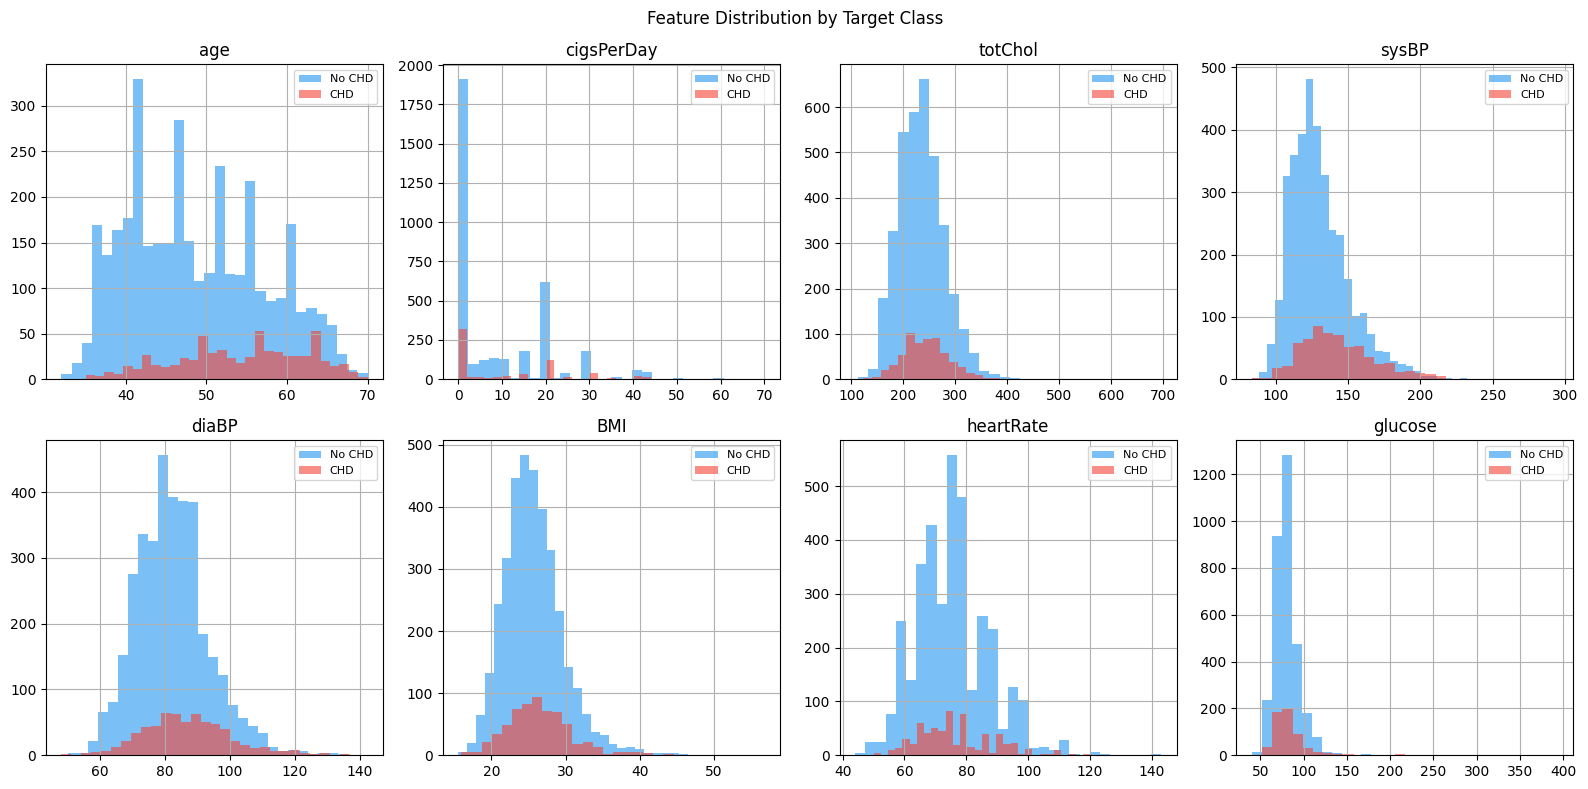

In [29]:
# Feature Distributions by CHD status
continuous_features = ["age","cigsPerDay","totChol","sysBP","diaBP","BMI","heartRate","glucose"]

fig, ax = plt.subplots(2,4,figsize=(16,8))
ax = ax.flatten()
for i, feature in enumerate(continuous_features):
    df[df['TenYearCHD'] == 0][feature].dropna().hist(
        ax=ax[i], bins=30, alpha=0.6, color='#2196F3', label='No CHD')
    df[df['TenYearCHD'] == 1][feature].dropna().hist(
        ax=ax[i], bins=30, alpha=0.6, color='#F44336', label='CHD')
    ax[i].set_title(feature)
    ax[i].legend(fontsize=8)
plt.suptitle("Feature Distribution by Target Class")
plt.tight_layout()
plt.show()


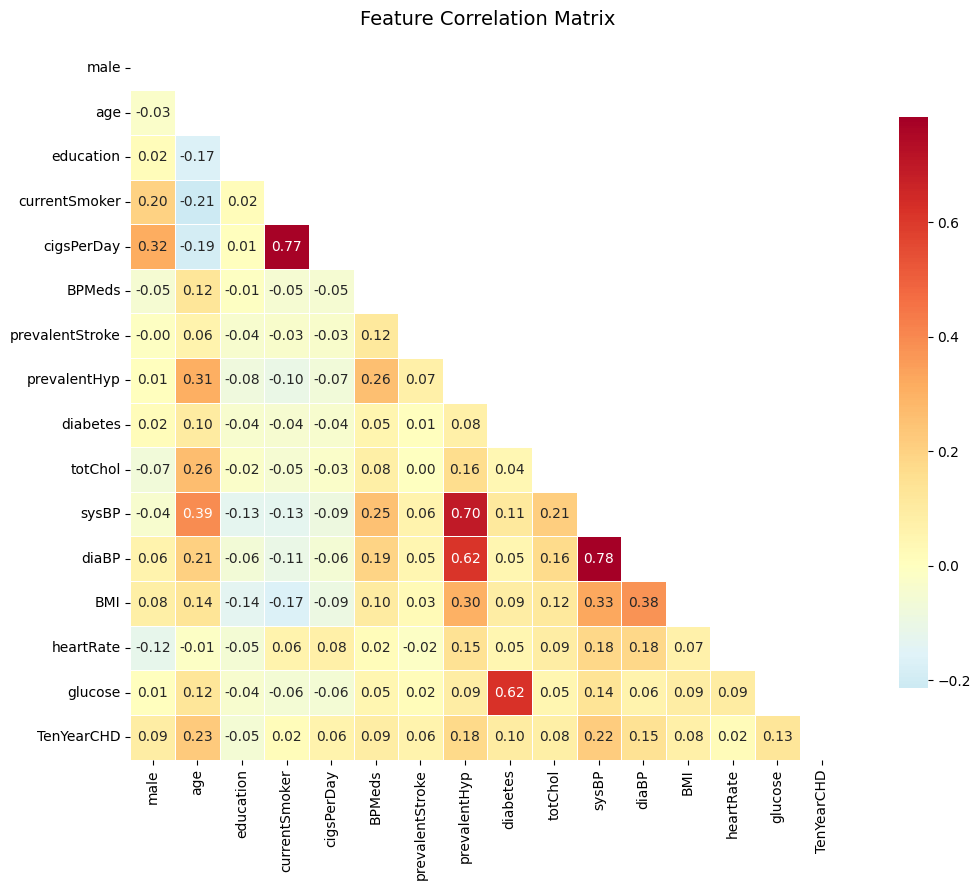

In [33]:
# Correlation Heatmap
plt.figure(figsize=(12, 9))
corr_matrix = df.corr()
mask = np.triu(np.ones_like(corr_matrix , dtype=bool))
sns.heatmap(corr_matrix,mask=mask , annot=True , fmt='.2f',cmap='RdYlBu_r', center=0,square=True,linewidth=0.5,cbar_kws={'shrink':0.8})
plt.title("Feature Correlation Matrix",fontsize=14,pad=15)
plt.tight_layout()
plt.show()
